In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import wandb
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from matplotlib.ticker import FuncFormatter, NullLocator
from soph.utils.config_generator import flatten

/home/shikai_q/miniconda3/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
def get_runs(project, filters=None, samples=500):
    """Fetch runs from wandb and return a DataFrame with history and varying config columns."""
    api = wandb.Api()
    runs = api.runs(project, filters=filters or {}, order="-created_at")
    rows = []
    for run in runs:
        config = flatten({k: v for k, v in run.config.items() if not k.startswith("_")})
        hist = pd.DataFrame(run.history(samples=samples))
        rows.append({**config, 'history': hist})
    df = pd.DataFrame(rows)
    fixed_cols = [c for c in df.columns if c != 'history' and df[c].apply(str).nunique() <= 1]
    df = df.drop(columns=fixed_cols)
    return df

In [4]:
filters = {
    "config.tag": 'markov_hidden_kl_capped_sweep',
    "config.D": 128,
    "config.L": 3,
    "config.width": 512,
    "config.T": 3000,
    "config.seed": 0,
    "config.max_kl": 0.01,
    "state": "finished",
}
runs = get_runs("shikai/requential", filters)
runs = runs.sort_values('meta/hidden_params')
print(f'{len(runs)} runs loaded')

6 runs loaded


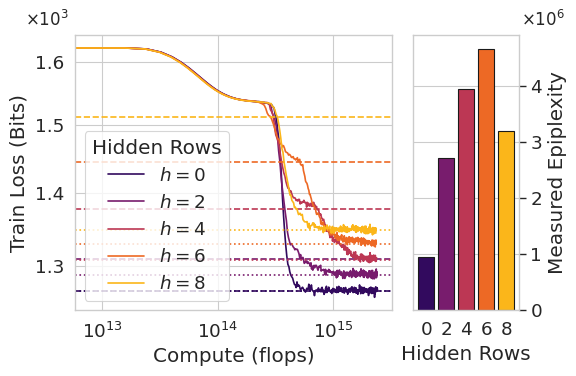

In [5]:
sns.set(style='whitegrid')
sns.set_context("paper", font_scale=1.5)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4),
                               gridspec_kw={'width_ratios': [6, 2]})

try:
    key = 'hidden_params'
    runs[key]
except KeyError:
    key = 'meta/nbits'

width = 512
unique_nbits = [0, 2, 4, 6, 8]
colors = sns.color_palette("inferno", n_colors=len(unique_nbits))

ax1.set_xscale('log')
ax1.set_yscale('log')

for i, n in enumerate(unique_nbits):
    h = runs[runs[key] == n]['history'].iloc[0]
    h['ema_student_loss'] = h['ema_student_loss'].replace('NaN', np.nan)
    ax1.plot(h['compute'], width * h['ema_student_loss'] / np.log(2) / 1e3,
             color=colors[i], label=f'$h={int(n)}$')
    unigram_loss = runs[runs[key] == n]['gram_loss_1'].iloc[0]
    min_loss = runs[runs[key] == n]['gram_loss_2'].iloc[0]
    ax1.axhline(unigram_loss * width / np.log(2) / 1e3, color=colors[i], linestyle='--')
    ax1.axhline(min_loss * width / np.log(2) / 1e3, color=colors[i], linestyle=':')

ax1.set_xlabel('Compute (flops)')
ax1.set_ylabel('Train Loss (Bits)')
ax1.legend(title='Hidden Rows')
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x:g}'))
ax1.yaxis.set_minor_locator(NullLocator())
ax1.set_yticks([1.3, 1.4, 1.5, 1.6])
ax1.set_yticklabels(['1.3', '1.4', '1.5', '1.6'])
ax1.text(-0.02, 1.02, r'$\times 10^3$', transform=ax1.transAxes,
         va='bottom', ha='right', fontsize=12)

ends = []
for n in unique_nbits:
    areas = []
    for hist in runs[runs[key] == n]['history']:
        areas.append(hist['K_req'].iloc[-1])
    ends.append(np.vstack(areas).mean(axis=0)[-1] / 1e6)

ax2.bar([int(n) for n in unique_nbits], ends, color=colors, width=1.6, edgecolor='k')
ax2.set(xlabel='Hidden Rows')
ax2.yaxis.set_label_position('right')
ax2.yaxis.tick_right()
ax2.set_ylabel('Measured Epiplexity')
ax2.set_xticks([int(n) for n in unique_nbits])
ax2.xaxis.grid(False)
ax2.yaxis.grid(True)
ax2.text(1.02, 1.02, r'$\times 10^6$', transform=ax2.transAxes,
         va='bottom', ha='left', fontsize=12)

plt.tight_layout()
plt.show()